**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 01 - Manejo de archivos y obtención de datos organizacionales**

## Complemento

Este notebook se complementa con la presentación: **Datos e IA.pdf**

Te recomendamos leer el PDF para trabajar con este notebook y tener una mejor comprensión de los conceptos teóricos.

## ¿Qué vamos a hacer en esta clase?

Toda la materia se apoya en un gesto que vamos a repetir cien veces: **traer datos a Python y mirarlos**.
Hoy aprendemos a hacerlo bien, con datos de una organización real.

| Parte | Tema | Qué nos llevamos |
|---|---|---|
| **A** | ¿De dónde salen los datos? | Los 3 formatos que te vas a cruzar siempre |
| **B** | El problema de las rutas | Por qué a tu compañero le anda y a vos no |
| **C** | Cargar: CSV, Excel y JSON | `read_csv`, `read_excel`, `read_json` |
| **D** | Primer contacto con la tabla | `shape`, `head`, `info`, `describe` |
| **E** | Seleccionar y filtrar | Quedarse con lo que importa |
| **F** | Guardar el resultado | `to_csv`, `to_excel` |


## Objetivos de la clase

- Distinguir una **ruta relativa** de una **absoluta**, y escribirlas sin romperlas en Windows
- Leer un CSV controlando **separador**, **decimal** y **encoding**
- Diagnosticar los dos errores clásicos: *archivo no encontrado* y *acentos rotos*
- Leer y escribir Excel, CSV y JSON
- Hacer el **primer inventario** de una tabla que no escribimos nosotros

Arrancamos importando las librerías. Esta celda va a estar al principio de **todos** los notebooks de la materia.

In [54]:
import pandas as pd               # pandas: la librería para trabajar con tablas
import numpy as np                # numpy: cálculo numérico
import matplotlib.pyplot as plt   # matplotlib: gráficos

pd.set_option("display.float_format", "{:,.2f}".format)   # que los números se vean con 2 decimales y separador de miles

---
# 📁 Parte A — ¿De dónde salen los datos?

En una organización los datos casi nunca llegan en un formato lindo. Llegan así:

| Formato | Extensión | De dónde suele venir | Cómo se lee |
|---|---|---|---|
| **CSV** | `.csv` | Exportación de un sistema, ERP, Google Sheets | `pd.read_csv()` |
| **Excel** | `.xlsx` `.xls` | Alguien de administración, con colores y celdas combinadas | `pd.read_excel()` |
| **JSON** | `.json` | Una API, un sistema web | `pd.read_json()` |

**CSV** significa *Comma Separated Values*: es un archivo de texto plano donde cada línea es una fila
y las columnas van separadas por comas. Si lo abrís con el Bloc de notas, lo podés leer. 

```
Fecha,Producto,Vendedor,Ciudad,Cantidad,Precio_Unitario
2024-01-01,Monitor,Juan,Mendoza,6,23030
2024-01-02,Notebook,Lucía,La Plata,7,87838
```

> ⚠️ **Ojo con el CSV en castellano.** En Argentina Excel a veces usa `;` como separador y `,` como
> decimal. Si al cargar te queda **todo en una sola columna**, probá `pd.read_csv(ruta, sep=";")`.

---
# 🗺️ Parte B — El problema de las rutas

Esta es **la** causa número uno de que un notebook no ande. Python no adivina dónde está tu archivo:
hay que decírselo con una **ruta**.

| Tipo de ruta | Ejemplo | Problema |
|---|---|---|
| **Absoluta** | `C:\Users\juan\Escritorio\ventas.csv` | Solo funciona en **tu** computadora |
| **Relativa** | `../DF/ventas.csv` | Funciona si respetás la estructura de carpetas |
| **URL** | `https://raw.githubusercontent.com/.../ventas.csv` | ✅ Funciona en todos lados |

En esta materia usamos **CASI siempre la URL**: así el notebook corre igual en Colab, en tu casa y en la facultad,
sin que nadie tenga que editar nada ni montar Google Drive.

### Windows y la barra invertida

Las rutas que copiás del Explorador vienen con **barra invertida** `\`, y Python usa ese símbolo
para otra cosa (`\n` es un salto de línea). Por eso una ruta pegada tal cual **ni siquiera llega a
ejecutarse**: tira `SyntaxError`.

> ✅ **La regla:** cambiá las `\` por `/` y listo. Funciona igual en Windows, Mac, Linux y Colab.

In [55]:
ruta = "C:/Users/Ana/Downloads/ventas.csv"   # barra normal: siempre funciona

print(ruta)

C:/Users/Ana/Downloads/ventas.csv


### Cuando el archivo no aparece

El error más frecuente de toda la materia:

```python
pd.read_csv("ventsa.csv")
```
```text
FileNotFoundError: [Errno 2] No such file or directory: 'ventsa.csv'
```

**No es un error misterioso: te está diciendo exactamente qué ruta buscó.** Copiá esa ruta del mensaje
y comparala con dónde está el archivo. Las tres causas son siempre las mismas:

1. El archivo no está donde creés.
2. El nombre tiene un error de tipeo (`ventsa` en vez de `ventas`).
3. El notebook está corriendo desde otra carpeta.

In [56]:
# Esta variable la vamos a reutilizar en todas las clases.
# Apunta a la carpeta DF/ del repositorio de la materia en GitHub.
URL = "https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/"

print(URL + "ventas.csv")   # así se arma la dirección de cada archivo

https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/ventas.csv


---
# 🐼 Un paréntesis: ¿qué es pandas?

Venimos escribiendo `pd.read_csv()` sin haber dicho **qué es** ese `pd`. Vamos a pararnos un minuto
acá, porque es la librería que vas a usar en toda la materia.

**pandas es la librería que le enseña a Python a trabajar con tablas.**

Python solo, de fábrica, sabe manejar números, textos y listas. No sabe qué es una columna, ni una
fila, ni cómo agrupar por categoría. Todo eso lo agrega pandas.

> 💡 **La forma más rápida de entenderlo:** pandas es **Excel, pero escrito en código**. Las mismas
> operaciones que hacés con el mouse —filtrar, ordenar, sumar una columna, hacer una tabla
> dinámica— pasan a estar escritas.

### ¿Y por qué no usar Excel directamente?

| | Excel | pandas |
|---|---|---|
| **Rehacer el trabajo del mes que viene** | Repetir todos los clicks | Volver a correr el código |
| **Cuántas filas aguanta** | Se pone lento con miles | Millones sin despeinarse |
| **Qué le hiciste a los datos** | Hay que acordarse | **Está escrito**, paso por paso |
| **Si te equivocaste** | Buscar dónde | Corregís una línea y corrés de nuevo |

Lo importante no es la velocidad: es que **el trabajo queda escrito**. Dentro de seis meses, cuando
alguien pregunte cómo salió ese número, la respuesta está en el código y no en tu memoria.

### Las dos piezas de pandas

Toda la librería gira alrededor de dos objetos, y conviene tener clara la diferencia:

| | Qué es | En Excel sería |
|---|---|---|
| **`DataFrame`** | La **tabla entera**: filas y columnas, con nombres | Una hoja completa |
| **`Series`** | **Una sola columna** de esa tabla | Una columna |

Cuando pedís una columna de un DataFrame, lo que obtenés es una Series. Y casi todo lo que
aprendiste en la clase 00 sigue valiendo: una Series se parece bastante a una lista, pero **sabe
hacer cuentas sobre todos sus elementos a la vez**.

In [ ]:
import pandas as pd

# Un DataFrame se puede armar a mano desde un diccionario:
# cada clave es el nombre de una columna (¿te suena de la clase 00?)
ventas_ejemplo = pd.DataFrame({
    "sucursal": ["Centro", "Norte", "Sur"],
    "unidades": [120, 95, 145],
    "precio":   [3400, 3400, 3200],
})

print("Un DataFrame (la tabla entera):")
print(ventas_ejemplo)

print("\nUna Series (una sola columna):")
print(ventas_ejemplo["unidades"])

print("\nY la Series sabe operar sobre todos sus valores de una vez:")
print("Total de unidades:", ventas_ejemplo["unidades"].sum())

### Por qué siempre se escribe `pd`

```python
import pandas as pd
```

Esa línea significa: *"traé la librería pandas y, para no escribir `pandas` cada vez, llamala `pd`"*.

**Es una convención universal.** Cualquier código de pandas que encuentres en internet, en la
documentación o en un libro va a usar `pd`. Podrías ponerle otro nombre, pero no lo hagas: se lee
peor y nadie lo hace.

> 🎯 **Lo que hay que retener:** `pd` es pandas, un **DataFrame** es una tabla y una **Series** es
> una columna. Con eso alcanza para lo que viene. Ahora sí, vamos a traer datos de verdad.

---
# 📥 Parte C — Cargar los datos

## C1. Un CSV

Vamos a trabajar con las **ventas de una empresa de tecnología**: 200 operaciones con fecha, producto,
vendedor, ciudad, cantidad y precio.

In [57]:
ventas = pd.read_csv(URL + "ventas.csv")   # read_csv: leer un archivo CSV y devolver un DataFrame

ventas.head()   # head(): muestra las primeras 5 filas

,Fecha,Producto,Vendedor,Ciudad,Cantidad,Precio_Unitario
0,2024-01-01,Monitor,Juan,Mendoza,6,23030
1,2024-01-02,Notebook,Lucía,La Plata,7,87838
2,2024-01-03,Teclado,Juan,Córdoba,3,89717
3,2024-01-04,Notebook,Juan,Mendoza,7,43638
4,2024-01-05,Notebook,María,Córdoba,3,72067


Lo que acabamos de crear se llama **DataFrame**: una tabla con filas y columnas, como una hoja de Excel
pero manejable con código.

- Cada **fila** es una observación (acá: una venta).
- Cada **columna** es una variable (fecha, producto, cantidad...).
- El número gris de la izquierda es el **índice**: el nombre de cada fila. Arranca en **0**, no en 1.

## C2. Un Excel

Cambia una sola palabra: `read_excel` en lugar de `read_csv`. Usamos las notas de la cursada de 2024.

In [58]:
notas = pd.read_excel(URL + "notas_2024.xlsx")   # read_excel: leer una planilla de Excel

notas.head()

,Registro,1 Parcial,2 Parcial,Situación,Nota final
0,800948,A,A,A,A
1,811565,4,2,Recupera 2 P,2
2,812864,2,A,Insuficiente,2
3,813475,2,A,Insuficiente,2
4,813477,A,A,A,A


> 📌 **Si el Excel tiene varias hojas**, agregás el argumento `sheet_name`:
> ```python
> pd.read_excel(ruta, sheet_name="Ventas2024")   # por nombre
> pd.read_excel(ruta, sheet_name=0)              # o por posición (0 = la primera)
> ```
>


## C3. Un JSON

Los datos que vienen de una **API** (un sistema que te entrega información por internet) suelen llegar
en formato JSON. Se lee con `read_json`.

In [59]:
# lines=True porque este archivo tiene un registro JSON por línea
monitores = pd.read_json(URL + "ventas_monitores.json", lines=True)

monitores.head(3)

,Fecha,Producto,Vendedor,Ciudad,Cantidad,Precio_Unitario,TotalVenta
0,1704067200000,Monitor,Juan,Mendoza,6,23030,138180
1,1704931200000,Monitor,Sofía,Córdoba,1,51271,51271
2,1705363200000,Monitor,María,Mendoza,8,55448,443584


Fijate en la columna `Fecha`: son números larguísimos. Eso pasa porque el JSON guarda las fechas como
*milisegundos desde 1970* (el "tiempo Unix"). Se arregla con una línea:

In [60]:
# to_datetime: convertir una columna a formato fecha. unit="ms" avisa que el número está en milisegundos
monitores["Fecha"] = pd.to_datetime(monitores["Fecha"], unit="ms")

monitores.head(3)

,Fecha,Producto,Vendedor,Ciudad,Cantidad,Precio_Unitario,TotalVenta
0,2024-01-01,Monitor,Juan,Mendoza,6,23030,138180
1,2024-01-11,Monitor,Sofía,Córdoba,1,51271,51271
2,2024-01-16,Monitor,María,Mendoza,8,55448,443584


---
## C4. Cuando el CSV viene "en criollo"

Un CSV exportado desde un Excel en español **no** viene como pandas espera. Excel usa punto y coma
para separar columnas y coma para los decimales:

```
sucursal;importe
Neuquén;1234,50
```

Si lo leés con la configuración por defecto, pandas busca comas para cortar columnas y te devuelve
**una sola columna gigante** con todo adentro.

### La tabla que te va a salvar

Cuando una lectura sale mal, el **síntoma** te dice qué parámetro tocar:

| Síntoma en la tabla | Causa probable | Qué agregar |
|---|---|---|
| Una sola columna larguísima | El separador no era la coma | `sep=";"` |
| Los números aparecen como texto | La coma decimal no se reconoció | `decimal=","` |
| Los acentos salen rotos (`NeuquÃ©n`) | El encoding no era el correcto | `encoding="latin-1"` |
| Las columnas salen corridas | Hay comas o comillas dentro del texto | revisar el archivo original |

Probémoslo. Primero fabricamos un CSV "a la argentina":

In [61]:
# Creamos un archivo como lo exportaría un Excel en español
ejemplo = pd.DataFrame({
    "sucursal": ["Neuquén", "Bariloche", "Córdoba"],
    "importe":  [1234.50, 980.75, 2500.00],
})

ejemplo.to_csv("ventas_criollo.csv", sep=";", decimal=",", index=False, encoding="utf-8")

# Miramos el archivo crudo, tal como está escrito en el disco
print(open("ventas_criollo.csv", encoding="utf-8").read())

sucursal;importe
Neuquén;1234,5
Bariloche;980,75
Córdoba;2500,0



In [62]:
# Lectura INGENUA: pandas busca comas y no las encuentra
mal = pd.read_csv("ventas_criollo.csv")

print("Dimensiones:", mal.shape, "  ← una sola columna: ahí está el síntoma")
mal

Dimensiones: (3, 1)   ← una sola columna: ahí está el síntoma


,sucursal;importe
Neuquén;1234,5
Bariloche;980,75
Córdoba;2500,0


In [63]:
# Lectura CORRECTA: le avisamos cómo viene el archivo
bien = pd.read_csv("ventas_criollo.csv", sep=";", decimal=",")

print("Dimensiones:", bien.shape)
print("\nTipos de dato:")
print(bien.dtypes)          # ahora importe es float64, no texto
bien

Dimensiones: (3, 2)

Tipos de dato:
sucursal     object
importe     float64
dtype: object


,sucursal,importe
0,Neuquén,"1,234.50"
1,Bariloche,980.75
2,Córdoba,"2,500.00"


### 🔤 Los acentos rotos: qué es un *encoding*

Un archivo de texto **no guarda letras: guarda números** (bytes). El *encoding* es la tabla que dice
qué letra le corresponde a cada número. Si escribís con una tabla y leés con otra, salen los
famosos `NeuquÃ©n`.

Es exactamente como un código de artículos: si tu sistema dice que el `105` es "monitor" y el del
proveedor dice que el `105` es "teclado", los dos leen el mismo número y entienden cosas distintas.
El archivo **no está roto**: se está leyendo con la tabla equivocada.

#### Las tres tablas que te vas a cruzar

| | Cuántos caracteres | Cuánto ocupa cada letra | De dónde sale |
|---|---|---|---|
| **ASCII** | 128 | 1 byte | El original de los años 60. **No tiene ñ ni tildes.** |
| **latin-1** *(ISO-8859-1)* | 256 | 1 byte | Le agrega los acentos de Europa occidental: `á é í ó ú ñ ü` |
| **cp1252** *(Windows-1252)* | 256 | 1 byte | La versión de Microsoft de latin-1. **Es la que usa el Excel en español en Windows.** |
| **utf-8** | Todos (+150.000) | 1 a 4 bytes | El estándar actual. Cubre todos los idiomas y los emojis. |

**latin-1 y cp1252 son casi iguales**: se diferencian en 27 posiciones que latin-1 deja vacías y
Windows aprovechó para las comillas tipográficas (`" "`), la rayita larga (`—`) y el símbolo `€`.
Por eso, cuando un archivo argentino viejo no abre con `utf-8`, probar `latin-1` casi siempre alcanza.

#### Por qué `é` se convierte en `Ã©`

Acá está el truco, y entenderlo te ahorra horas:

- En **utf-8**, la `é` no entra en un byte: se guarda con **dos** → `0xC3 0xA9`.
- Si ese archivo se lee con **latin-1**, que asume **un byte = una letra**, esos dos bytes se leen
  por separado: `0xC3` es `Ã` y `0xA9` es `©`. Resultado: **`Ã©`**.

Y al revés: si el archivo está en latin-1, la `é` es el byte `0xE9` solito. utf-8 espera que después
de un byte alto venga otro que lo acompañe, no lo encuentra, y corta con `UnicodeDecodeError`.

| Qué pasa | Cómo se ve | Qué significa |
|---|---|---|
| Abre, pero mal | `Neuquén` → `NeuquÃ©n` | El archivo es **utf-8** y lo leíste como **latin-1** |
| No abre | `UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe9` | El archivo es **latin-1/cp1252** y lo leíste como **utf-8** |
| Aparece `ï»¿` al principio | `ï»¿sucursal` | Excel le puso un **BOM**: leelo con `encoding="utf-8-sig"` |

> 🎯 **La receta, en orden:** probá `utf-8` (es lo que pandas asume). Si falla o los acentos salen
> mal, probá `latin-1`. Si el archivo salió de un Excel y la primera columna tiene basura adelante,
> `utf-8-sig`. Con esos tres cubrís prácticamente todo lo que te van a mandar.

In [64]:
# Veamos los bytes de verdad: la misma palabra guardada con dos tablas distintas
palabra = "Neuquén"

print("En utf-8   :", palabra.encode("utf-8"),   "←", len(palabra.encode("utf-8")), "bytes")
print("En latin-1 :", palabra.encode("latin-1"), "←", len(palabra.encode("latin-1")), "bytes")
print()
print("La 'é' en utf-8 ocupa DOS bytes; en latin-1, uno solo. De ahí viene todo el problema.")

En utf-8   : b'Neuqu\xc3\xa9n' ← 8 bytes
En latin-1 : b'Neuqu\xe9n' ← 7 bytes

La 'é' en utf-8 ocupa DOS bytes; en latin-1, uno solo. De ahí viene todo el problema.


In [65]:
# El mojibake, paso a paso: escribo en utf-8 y leo como si fuera latin-1
bytes_utf8 = "Neuquén".encode("utf-8")
mal_leido  = bytes_utf8.decode("latin-1")

print("Original         :", "Neuquén")
print("Leído con latin-1:", mal_leido, "  ← el famoso mojibake")

# Y al revés: escribo en latin-1 y trato de leer como utf-8
bytes_latin = "Neuquén".encode("latin-1")
try:
    bytes_latin.decode("utf-8")
except UnicodeDecodeError as e:
    print("\nLeído con utf-8  → UnicodeDecodeError:", e.reason)

Original         : Neuquén
Leído con latin-1: NeuquÃ©n   ← el famoso mojibake

Leído con utf-8  → UnicodeDecodeError: invalid continuation byte


> 💡 **Buena noticia:** el mojibake es **reversible**. Si el texto ya te llegó como `NeuquÃ©n`,
> se recupera haciendo el camino inverso: `texto.encode("latin-1").decode("utf-8")`.
> Nada se perdió; solo estaba mal traducido.

In [66]:
# Rescatar un texto que llegó roto
roto_texto = "NeuquÃ©n"
recuperado = roto_texto.encode("latin-1").decode("utf-8")

print("Como llegó :", roto_texto)
print("Recuperado :", recuperado)

Como llegó : NeuquÃ©n
Recuperado : Neuquén


In [67]:
# Leemos a propósito con el encoding equivocado para ver el síntoma
roto = pd.read_csv("ventas_criollo.csv", sep=";", decimal=",", encoding="latin-1")

print("Con el encoding EQUIVOCADO:")
print(roto["sucursal"].tolist())

print("\nCon el encoding CORRECTO:")
print(bien["sucursal"].tolist())

Con el encoding EQUIVOCADO:
['NeuquÃ©n', 'Bariloche', 'CÃ³rdoba']

Con el encoding CORRECTO:
['Neuquén', 'Bariloche', 'Córdoba']


> 📎 **¿Y si querés usar un archivo tuyo?** En Colab, el panel de carpetas 📁 de la izquierda tiene
> un botón para subir archivos. Una vez subido, se lee con el nombre solo, sin ninguna ruta:
> ```python
> mis_datos = pd.read_csv("mi_archivo.csv")
> ```
> También se puede hacer desde código:
> ```python
> from google.colab import files
> files.upload()
> ```
> ⚠️ Ese archivo **se borra cuando se cierra la sesión** de Colab. No es un lugar donde guardar nada.

---
# 🔍 Parte D — Primer contacto con la tabla

Ya tenemos los datos adentro. **Antes de calcular nada**, hay que mirarlos. Siempre estas cuatro preguntas:

| Pregunta | Comando |
|---|---|
| ¿Cuán grande es? | `df.shape` |
| ¿Qué pinta tiene? | `df.head()` |
| ¿De qué tipo es cada columna y dónde faltan datos? | `df.info()` |
| ¿Cómo se distribuyen los números? | `df.describe()` |

In [68]:
# shape: devuelve (cantidad de filas, cantidad de columnas)
print("Dimensiones:", ventas.shape)
print("Filas:", ventas.shape[0], "| Columnas:", ventas.shape[1])

Dimensiones: (200, 6)
Filas: 200 | Columnas: 6


In [69]:
# info(): tipo de dato de cada columna y cuántos valores NO nulos tiene
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Fecha            200 non-null    object
 1   Producto         200 non-null    object
 2   Vendedor         200 non-null    object
 3   Ciudad           200 non-null    object
 4   Cantidad         200 non-null    int64 
 5   Precio_Unitario  200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


**Cómo se lee un `info()`:**

- `Non-Null Count` → cuántas filas tienen dato. Si dice menos que el total, **hay datos faltantes**.
- `Dtype` → el tipo:

| Dtype | Significa | Cuidado |
|---|---|---|
| `int64` | Número entero | |
| `float64` | Número con decimales | |
| `object` | Texto (o mezcla) | ⚠️ Si una columna numérica figura como `object`, hay algún texto colado |
| `datetime64` | Fecha | Hay que convertirla, no viene sola |

Fijate que `Fecha` figura como `object`: pandas la leyó como **texto**, no como fecha. Lo arreglamos:

In [70]:
ventas["Fecha"] = pd.to_datetime(ventas["Fecha"])   # convertir el texto a fecha de verdad

ventas.dtypes   # dtypes: ver el tipo de cada columna

Fecha              datetime64[ns]
Producto                   object
Vendedor                   object
Ciudad                     object
Cantidad                    int64
Precio_Unitario             int64
dtype: object

In [71]:
# describe(): estadísticas de las columnas numéricas
ventas.describe().round(2)

,Fecha,Cantidad,Precio_Unitario
count,200,200.00,200.00
mean,2024-04-09 12:00:00,4.76,"80,958.75"
min,2024-01-01 00:00:00,1.00,"5,235.00"
25%,2024-02-19 18:00:00,2.00,"46,359.50"
50%,2024-04-09 12:00:00,5.00,"82,079.50"
75%,2024-05-29 06:00:00,7.00,"121,216.25"
max,2024-07-18 00:00:00,9.00,"149,990.00"
std,NaN,2.62,"43,652.94"


Ese cuadro ya dice bastante del negocio:

- `count` → cuántos datos hay.
- `mean` → el promedio.
- `std` → el desvío estándar: qué tan dispersos están los valores.
- `min` y `max` → el mínimo y el máximo.
- `25%`, `50%`, `75%` → los cuartiles. El `50%` es la **mediana**: el valor del medio.

> 💡 Si el **promedio** y la **mediana** están muy lejos uno del otro, hay valores extremos tirando del promedio.
> Lo vamos a ver en detalle en la clase de métricas estadísticas.

### El inventario mínimo

Cuando te pasan una tabla que no escribiste vos, hacé **siempre** estos cinco controles antes de
calcular nada. No es burocracia: cada uno habilita una decisión.

| Control | Comando | Para qué sirve |
|---|---|---|
| **Tamaño** | `df.shape` | Detectar si faltó media carga |
| **Columnas** | `df.columns` | Comparar contra lo que te dijeron que venía |
| **Tipos** | `df.dtypes` / `df.info()` | Cazar fechas y números leídos como texto |
| **Resumen** | `df.describe()` | Encontrar valores imposibles o escalas raras |
| **Memoria** | `df.memory_usage(deep=True)` | Saber si vas a poder trabajarla |

> 🎯 **Inventariar no es analizar.** Es dejar por escrito qué material tenés antes de sacar
> conclusiones. Si te salteás este paso, cualquier error del archivo se te va a filtrar hasta el informe.

In [72]:
# El inventario completo de nuestra tabla de ventas, en una celda
print("1. TAMAÑO   :", ventas.shape)
print("2. COLUMNAS :", list(ventas.columns))
print("3. TIPOS    :")
print(ventas.dtypes.to_string())
print("4. MEMORIA  : %.2f MB" % (ventas.memory_usage(deep=True).sum() / 1024**2))
print("\nPeríodo que cubre:", ventas["Fecha"].min().date(), "→", ventas["Fecha"].max().date())

1. TAMAÑO   : (200, 6)
2. COLUMNAS : ['Fecha', 'Producto', 'Vendedor', 'Ciudad', 'Cantidad', 'Precio_Unitario']
3. TIPOS    :
Fecha              datetime64[ns]
Producto                   object
Vendedor                   object
Ciudad                     object
Cantidad                    int64
Precio_Unitario             int64
4. MEMORIA  : 0.04 MB

Período que cubre: 2024-01-01 → 2024-07-18


---
# ✂️ Parte E — Seleccionar y filtrar

Rara vez usamos la tabla entera. Estas cuatro operaciones cubren el 90% de los casos.

### Una columna

In [73]:
ventas["Producto"].head()          # corchetes con el nombre de la columna entre comillas

0     Monitor
1    Notebook
2     Teclado
3    Notebook
4    Notebook
Name: Producto, dtype: object

### Varias columnas — ojo con el **doble** corchete

`ventas["Producto"]` te da **una** columna. Para pedir varias, le pasás una **lista** de nombres,
y la lista también va entre corchetes. De ahí el `[[ ]]`.

In [74]:
ventas[["Producto", "Cantidad", "Precio_Unitario"]].head()

,Producto,Cantidad,Precio_Unitario
0,Monitor,6,23030
1,Notebook,7,87838
2,Teclado,3,89717
3,Notebook,7,43638
4,Notebook,3,72067


### Crear una columna nueva

Acá es donde los datos empiezan a servir. Tenemos cantidad y precio unitario, pero **no** el total facturado.
Lo calculamos:

In [75]:
ventas["Total"] = ventas["Cantidad"] * ventas["Precio_Unitario"]

ventas.head()

,Fecha,Producto,Vendedor,Ciudad,Cantidad,Precio_Unitario,Total
0,2024-01-01,Monitor,Juan,Mendoza,6,23030,138180
1,2024-01-02,Notebook,Lucía,La Plata,7,87838,614866
2,2024-01-03,Teclado,Juan,Córdoba,3,89717,269151
3,2024-01-04,Notebook,Juan,Mendoza,7,43638,305466
4,2024-01-05,Notebook,María,Córdoba,3,72067,216201


### Filtrar filas

Le pasamos una **condición** entre corchetes. Python evalúa la condición fila por fila y se queda
solo con las que dan verdadero.

In [76]:
# Solo las ventas de Córdoba
cordoba = ventas[ventas["Ciudad"] == "Córdoba"]

print("Ventas totales:", len(ventas))
print("Ventas en Córdoba:", len(cordoba))
cordoba.head()

Ventas totales: 200
Ventas en Córdoba: 42


,Fecha,Producto,Vendedor,Ciudad,Cantidad,Precio_Unitario,Total
2,2024-01-03,Teclado,Juan,Córdoba,3,89717,269151
4,2024-01-05,Notebook,María,Córdoba,3,72067,216201
9,2024-01-10,Notebook,Juan,Córdoba,7,39674,277718
10,2024-01-11,Monitor,Sofía,Córdoba,1,51271,51271
12,2024-01-13,Impresora,Juan,Córdoba,9,116076,1044684


In [77]:
# Dos condiciones a la vez:
#   &  significa "Y" (se tienen que cumplir las dos)
#   |  significa "O" (alcanza con una)
# Cada condición va entre paréntesis; no es opcional.
grandes = ventas[(ventas["Ciudad"] == "Córdoba") & (ventas["Total"] > 200_000)]

print("Ventas grandes en Córdoba:", len(grandes))
grandes.head()

Ventas grandes en Córdoba: 28


,Fecha,Producto,Vendedor,Ciudad,Cantidad,Precio_Unitario,Total
2,2024-01-03,Teclado,Juan,Córdoba,3,89717,269151
4,2024-01-05,Notebook,María,Córdoba,3,72067,216201
9,2024-01-10,Notebook,Juan,Córdoba,7,39674,277718
12,2024-01-13,Impresora,Juan,Córdoba,9,116076,1044684
18,2024-01-19,Mouse,Sofía,Córdoba,5,52915,264575


### Agrupar: la pregunta del jefe

*"¿Cuánto vendió cada vendedor?"* En Excel sería una tabla dinámica. Acá es una línea: `groupby`.

In [78]:
# groupby("Vendedor") → armar un grupo por cada vendedor
# ["Total"].sum()     → sumar la columna Total dentro de cada grupo
# sort_values(...)    → ordenar de mayor a menor
por_vendedor = ventas.groupby("Vendedor")["Total"].sum().sort_values(ascending=False)

por_vendedor

Vendedor
Lucía    21097076
Juan     17797334
María    16112904
Pedro    14999006
Sofía     9214950
Name: Total, dtype: int64

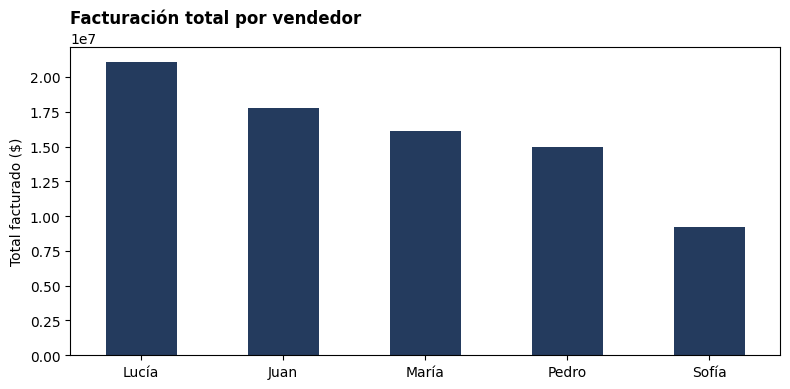

In [79]:
# Y lo mismo en un gráfico, para que se entienda de un vistazo

# subplots() crea el lienzo: fig = la hoja entera, ax = el recuadro donde se dibuja
# figsize=(ancho, alto) va en pulgadas
fig, ax = plt.subplots(figsize=(8, 4))

# pandas dibuja la Serie directamente. ax=ax le indica EN QUÉ recuadro dibujar
# (sin eso crea uno nuevo y quedan dos gráficos separados)
por_vendedor.plot(kind="bar", ax=ax, color="#243b5e")

ax.set_title("Facturación total por vendedor",   # el título del gráfico
             loc="left",                          # alineado a la izquierda: se lee mejor que centrado
             fontweight="bold")                   # en negrita

ax.set_xlabel("")                        # vacío a propósito: los nombres ya se leen abajo
ax.set_ylabel("Total facturado ($)")     # el eje Y siempre lleva la unidad

plt.xticks(rotation=0)   # nombres horizontales (por defecto matplotlib los rota y se leen mal)
plt.tight_layout()       # acomoda los márgenes para que no se corte ningún texto
plt.show()               # muestra el gráfico

---
# 💾 Parte F — Guardar el resultado

El trabajo no termina en la pantalla: casi siempre hay que devolver un archivo.

In [80]:
# index=False evita que se guarde el número de fila como si fuera una columna más
ventas.to_csv("ventas_con_total.csv", index=False)

print("Archivo guardado ✅")

Archivo guardado ✅


> 📌 **En Colab**, el archivo queda en la máquina virtual (panel de carpetas 📁 a la izquierda) y
> **se borra al cerrar la sesión**. Para bajarlo a tu computadora:
> ```python
> from google.colab import files
> files.download("ventas_con_total.csv")
> ```


---
# 📝 Ejercicios

Cada ejercicio practica **una parte de esta clase**, en el mismo orden en que las vimos. Si te
trabás en alguno, el contenido que necesitás está justo arriba.

Trabajamos con `productos_stock.csv`: el inventario de una distribuidora con 10 productos.

In [ ]:
stock = pd.read_csv(URL + "productos_stock.csv")
stock

**Ejercicio 1 · (Parte D — primer contacto).** ¿Cuántas filas y columnas tiene `stock`?
¿Qué tipo de dato tiene cada columna?

Prestá atención a una cosa: la columna de precios se llama `Precio unitario (€)`, **en euros**.
¿Te parece un detalle menor? Anotá qué problema puede traer eso si después cruzás esta tabla con
ventas en pesos.

In [ ]:
# Tu respuesta acá

**Ejercicio 2 · (Parte E — crear una columna).** Creá una columna `Valor_inventario` como
`Stock actual` × `Precio unitario (€)`.

¿Cuál es el producto con **más capital inmovilizado**? Es decir: ¿en qué producto la empresa tiene
más plata dormida en el depósito?

In [ ]:
# Tu respuesta acá

**Ejercicio 3 · (Parte E — filtrar filas).** Filtrá los productos con más de 30 `Días en stock`:
son los que se están quedando dormidos.

¿Cuántos son y cuánto dinero representan en total, sumando su `Valor_inventario`?

In [ ]:
# Tu respuesta acá

**Ejercicio 4 · (Parte E — agrupar).** Usando `groupby`, calculá las **ventas mensuales totales por
`Categoría`**.

Después ordená el resultado de mayor a menor con `.sort_values()`. ¿Qué categoría explica la mayor
parte de las ventas? ¿Coincide con la que tiene más capital inmovilizado?

In [ ]:
# Tu respuesta acá

**Ejercicio 5 · (Parte C4 — el CSV en criollo).** Este es el que más te va a servir en la vida real.

Guardá `stock` como un CSV "a la argentina", con `;` de separador y `,` de decimal:

```python
stock.to_csv("stock_criollo.csv", sep=";", decimal=",", index=False)
```

Y ahora:

1. Leelo **sin** avisarle nada a pandas: `pd.read_csv("stock_criollo.csv")`. ¿Cuántas columnas te
   quedaron? ¿Por qué?
2. Leelo **bien**, con los parámetros que corresponden.
3. Comprobá con `.dtypes` que los precios volvieron a ser números y no texto.

In [ ]:
# Tu respuesta acá

**Ejercicio 6 · (Parte F — guardar).** Guardá en un CSV solo los productos de la categoría con más
ventas, con las columnas `Producto`, `Stock actual` y `Valor_inventario`.

Acordate del `index=False`: si no, aparece una columna extra sin nombre que después molesta.

In [ ]:
# Tu respuesta acá

**Ejercicio 7 (integrador).** Cargá `ventas_monitores.csv` y compará su cantidad de filas con la de
`ventas.csv` **filtrado solo por monitores**.

```python
ventas = pd.read_csv(URL + "ventas.csv")
monitores = pd.read_csv(URL + "ventas_monitores.csv")
```

¿Dan lo mismo? **No.** Y ahí está el ejercicio: averiguá **por qué**.

1. ¿Cuántas filas tiene cada uno?
2. Mirá las columnas de los dos archivos: ¿son iguales?
3. Compará las fechas de cada uno. ¿Cubren el mismo período?
4. **La pregunta que importa:** si te pasan estos dos archivos y te piden "el total vendido en
   monitores", ¿cuál usarías? ¿Qué le preguntarías a quien te los mandó?

> 💼 Esto pasa **todo el tiempo** en una organización: dos archivos que dicen lo mismo y no
> coinciden. La respuesta profesional nunca es elegir el que más gusta, sino **preguntar** de dónde
> salió cada uno antes de informar un número.

In [ ]:
# Tu respuesta acá

---
## 🧭 Para la próxima

| Concepto | Comando |
|---|---|
| Cargar CSV / Excel / JSON | `pd.read_csv()` · `pd.read_excel()` · `pd.read_json()` |
| Tamaño de la tabla | `df.shape` |
| Primeras filas | `df.head()` |
| Tipos y faltantes | `df.info()` |
| Estadísticas | `df.describe()` |
| Una columna / varias | `df["col"]` · `df[["a", "b"]]` |
| Filtrar | `df[df["col"] > valor]` |
| Agrupar | `df.groupby("col")["otra"].sum()` |
| Guardar | `df.to_csv("archivo.csv", index=False)` |



---
## Referencias

- Lectura y escritura de datos en pandas: <https://pandas.pydata.org/docs/user_guide/io.html>
- Documentación de `read_csv`: <https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html>
- Material de cátedra — Laboratorio de Métodos Cuantitativos, FCE-UBA